<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/RBF_Interpolatoins_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Figure 1 - Schematic Boundary Strategy

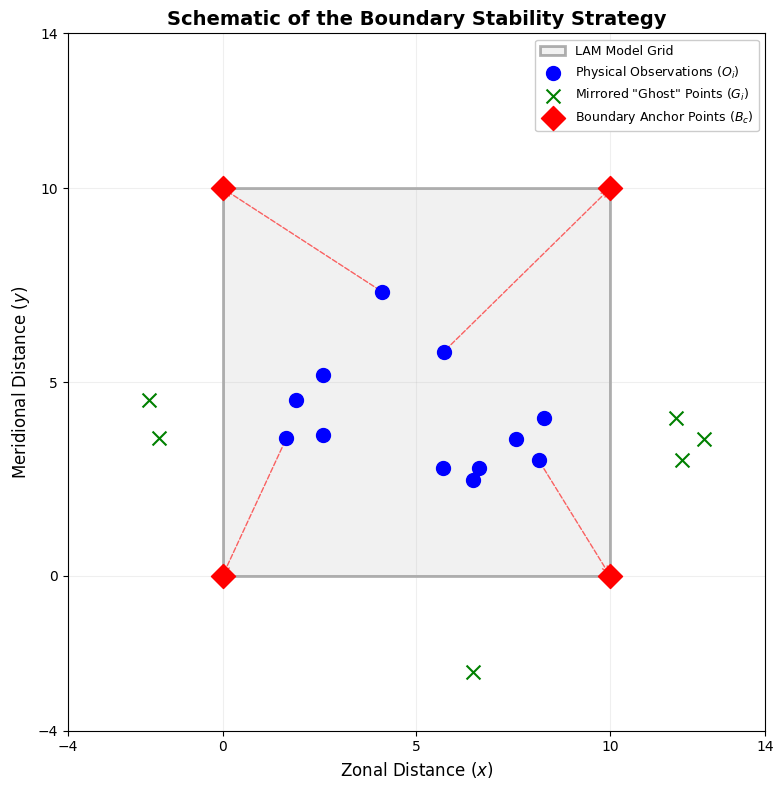

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -- Setup --
fig, ax = plt.subplots(figsize=(8, 8))
plt.xlim(-4, 14) # Expanded limits to show ghost points clearly
plt.ylim(-4, 14)

# 1. THE DOMAIN (Grid)
domain_rect = patches.Rectangle((0, 0), 10, 10, linewidth=2, edgecolor='black',
                                facecolor='lightgrey', alpha=0.3, label='LAM Model Grid')
ax.add_patch(domain_rect)

# 2. PHYSICAL OBSERVATIONS
np.random.seed(42)
n_obs = 12
obs_x = np.random.uniform(1.5, 8.5, n_obs)
obs_y = np.random.uniform(1.5, 8.5, n_obs)
ax.scatter(obs_x, obs_y, c='blue', marker='o', s=100, label='Physical Observations ($O_i$)', zorder=5)

# --- BC STRATEGY SCHEMATIC ---

# A) Meridional & Zonal Mirroring
buffer_val = 2.5
# Top/Bottom
near_top = obs_y > (10 - buffer_val)
near_bot = obs_y < (0 + buffer_val)
# Left/Right
near_right = obs_x > (10 - buffer_val)
near_left = obs_x < (0 + buffer_val)

# Top Mirror (Across y=10)
ax.scatter(obs_x[near_top], 20 - obs_y[near_top], c='green', marker='x', s=100, label='Mirrored "Ghost" Points ($G_i$)')
# Bottom Mirror (Across y=0)
ax.scatter(obs_x[near_bot], 0 - obs_y[near_bot], c='green', marker='x', s=100)
# Right Mirror (Across x=10)
ax.scatter(20 - obs_x[near_right], obs_y[near_right], c='green', marker='x', s=100)
# Left Mirror (Across x=0)
ax.scatter(0 - obs_x[near_left], obs_y[near_left], c='green', marker='x', s=100)

# B) Four Corner Anchoring (Snapping)
corner_coords = np.array([[0,0], [10,0], [0,10], [10,10]])
ax.scatter(corner_coords[:,0], corner_coords[:,1], c='red', marker='D', s=150, zorder=10, label='Boundary Anchor Points ($B_c$)')

# Draw arrows for snapping logic
for corner in corner_coords:
    dist = np.sqrt((obs_x - corner[0])**2 + (obs_y - corner[1])**2)
    nearest_idx = np.argmin(dist)
    ax.annotate("", xy=(corner[0], corner[1]), xytext=(obs_x[nearest_idx], obs_y[nearest_idx]),
                arrowprops=dict(arrowstyle="->", color='red', linestyle="--", alpha=0.6))

# Labels and Text
ax.set_aspect('equal')
plt.xlabel('Zonal Distance ($x$)', fontsize=12)
plt.ylabel('Meridional Distance ($y$)', fontsize=12)
plt.title('Schematic of the Boundary Stability Strategy', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9, framealpha=1)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.xticks([-4, 0, 5, 10, 14])
plt.yticks([-4, 0, 5, 10, 14])

plt.savefig('BC_sheme.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# Figure 2 - Idealized linear front

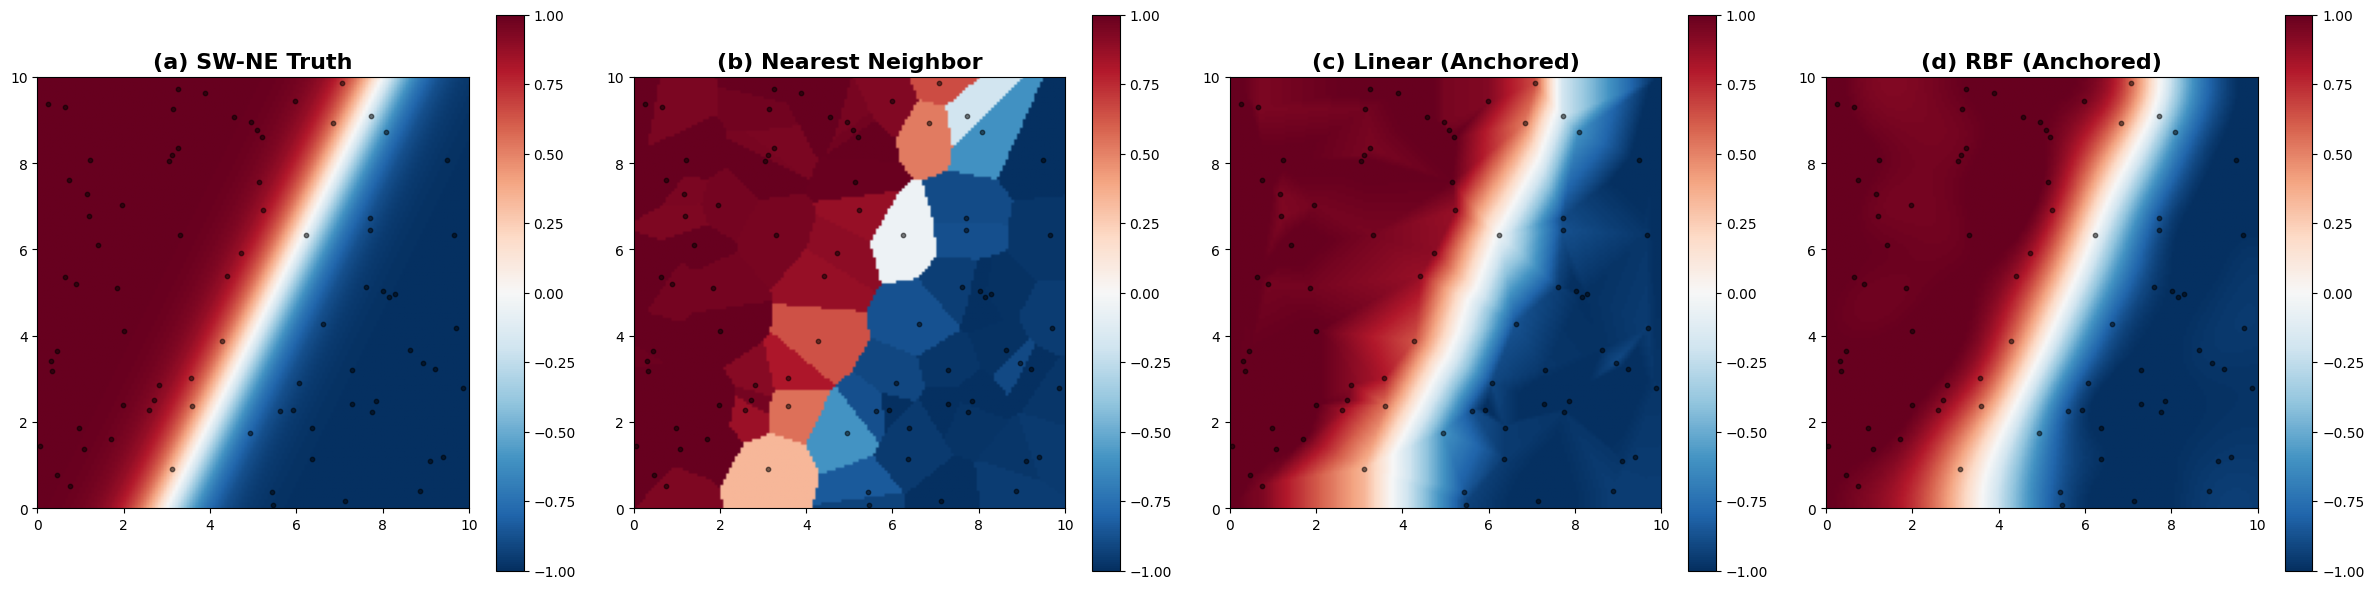

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf, NearestNDInterpolator, LinearNDInterpolator

# 1. Setup Grid and Synthetic Truth
grid_size = 150
x_coords = np.linspace(0, 10, grid_size)
y_coords = np.linspace(0, 10, grid_size)
X, Y = np.meshgrid(x_coords, y_coords)

# --- MODIFIED ALIGNMENT ---
# -X + 0.5*Y tilts the front from SW to NE.
# +3 shifts the center so the front crosses the middle of the 10x10 domain.
true_field = np.tanh(-X + 0.5 * Y + 3)

# 2. Generate Sparse Observations
n_obs = 80
obs_x = np.random.uniform(0, 10, n_obs)
obs_y = np.random.uniform(0, 10, n_obs)
# Sample truth + 0.05 Gaussian noise
obs_values = np.tanh(-obs_x + 0.5 * obs_y + 3) + np.random.normal(0, 0.05, n_obs)

# --- 3. THE "PERFECT SQUARE" ANCHORING LOGIC ---
# A) Meridional Mirroring (Y-axis)
buffer = 2.5
near_top = obs_y > 7.5
near_bottom = obs_y < 2.5

ghost_x_y = np.concatenate([obs_x[near_top], obs_x[near_bottom]])
ghost_y_y = np.concatenate([20 - obs_y[near_top], 0 - obs_y[near_bottom]])
ghost_val_y = np.concatenate([obs_values[near_top], obs_values[near_bottom]])

# B) The Four Corner Snaps
def get_corner_val(tx, ty):
    dist = (obs_x - tx)**2 + (obs_y - ty)**2
    return obs_values[np.argmin(dist)]

corner_x = np.array([0, 10, 0, 10])
corner_y = np.array([0, 0, 10, 10])
corner_val = np.array([get_corner_val(0,0), get_corner_val(10,0),
                       get_corner_val(0,10), get_corner_val(10,10)])

# Combine all points: Original + Y-Mirror + 4 Corners
aug_x = np.concatenate([obs_x, ghost_x_y, corner_x])
aug_y = np.concatenate([obs_y, ghost_y_y, corner_y])
aug_val = np.concatenate([obs_values, ghost_val_y, corner_val])

# 4. Interpolation Methods
nn_interp = NearestNDInterpolator(list(zip(obs_x, obs_y)), obs_values)
nn_res = nn_interp(X, Y)

lin_interp = LinearNDInterpolator(list(zip(aug_x, aug_y)), aug_val)
lin_res = lin_interp(X, Y)

rbf_interp = Rbf(aug_x, aug_y, aug_val, function='multiquadric', epsilon=1.2, smooth=0.1)
rbf_res = rbf_interp(X, Y)

# 5. Visualization
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
data = [true_field, nn_res, lin_res, rbf_res]
titles = ["(a) SW-NE Truth", "(b) Nearest Neighbor", "(c) Linear (Anchored)", "(d) RBF (Anchored)"]

for ax, d, t in zip(axes, data, titles):
    im = ax.imshow(d, extent=(0, 10, 0, 10), origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.scatter(obs_x, obs_y, c='black', s=10, alpha=0.5)
    ax.set_title(t, fontsize=16, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.savefig('Lfront.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# Figure 3 - Idealized wave front

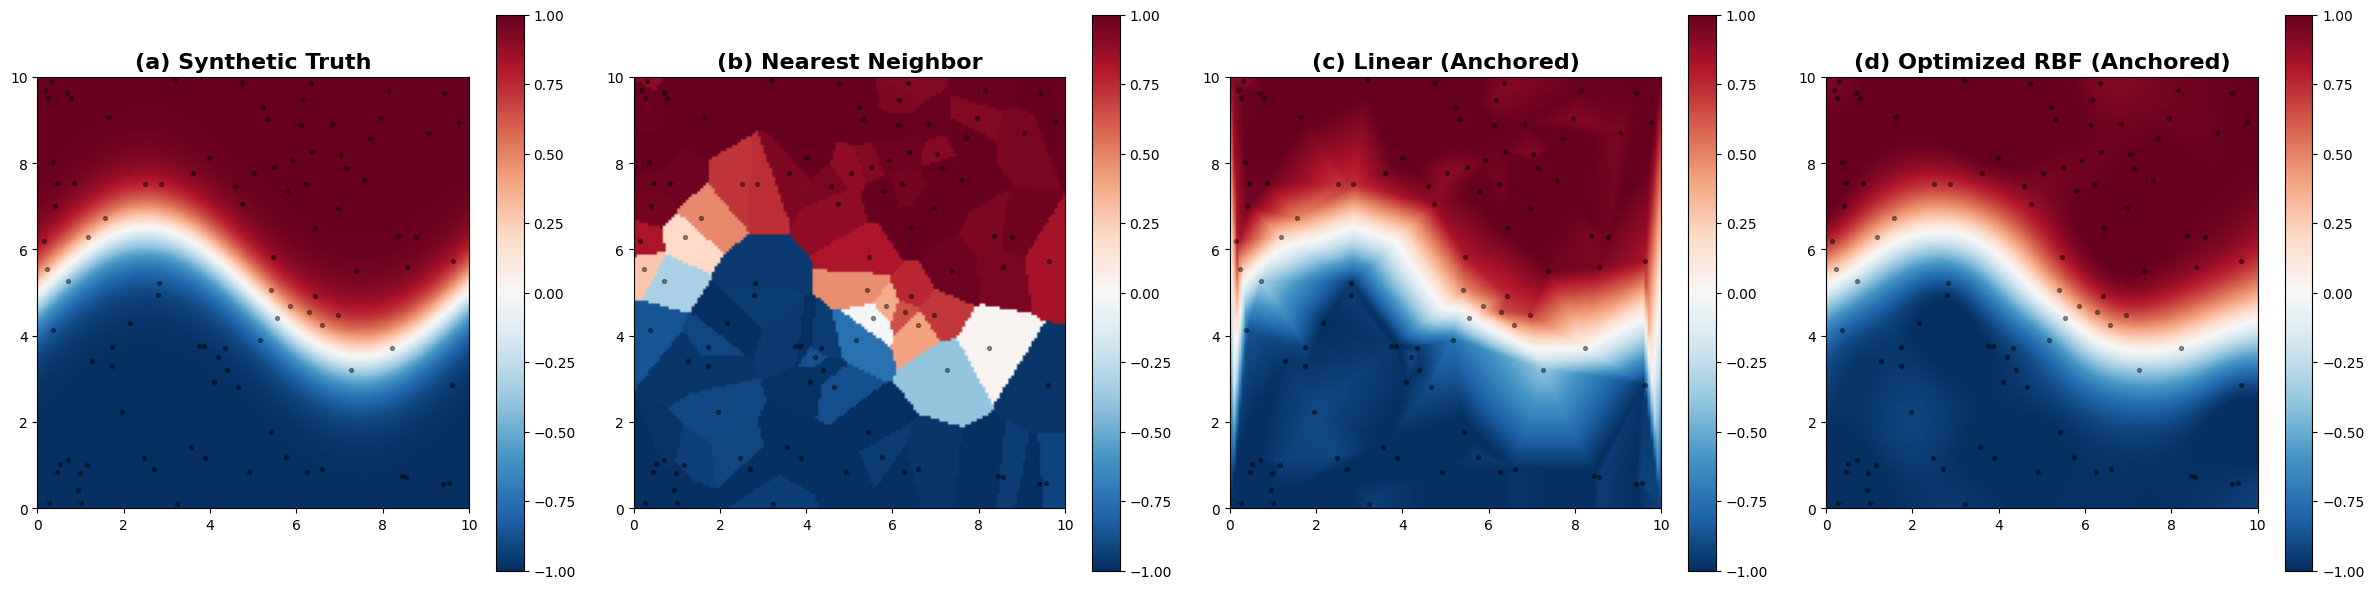

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf, NearestNDInterpolator, LinearNDInterpolator

# 1. Setup Grid and Synthetic Truth (Wavy Front)
grid_size = 150
x = np.linspace(0, 10, grid_size)
y = np.linspace(0, 10, grid_size)
X, Y = np.meshgrid(x, y)

# Wavy Front: tanh(Y - 5 - 1.5*sin(X*2pi/10))
amplitude = 1.5
freq = 2 * np.pi / 10
# The front is defined by a tanh transition centered on the wave
true_field = np.tanh(Y - 5 - amplitude * np.sin(X * freq))

# 2. Generate Sparse Random Observations (n=100)
n_obs = 100
obs_x = np.random.uniform(0, 10, n_obs)
obs_y = np.random.uniform(0, 10, n_obs)
# Sample truth + 0.05 Gaussian noise
obs_values = np.tanh(obs_y - 5 - amplitude * np.sin(obs_x * freq)) + np.random.normal(0, 0.05, n_obs)

# --- 3. THE "PERFECT SQUARE" ANCHORING LOGIC ---
# A) Meridional Mirroring (Y-axis) - As you suggested
y_min, y_max = 0, 10
buffer = 2.5
near_top = obs_y > (10 - buffer)
near_bottom = obs_y < (0 + buffer)

ghost_x_y = np.concatenate([obs_x[near_top], obs_x[near_bottom]])
ghost_y_y = np.concatenate([20 - obs_y[near_top], 0 - obs_y[near_bottom]])
ghost_val_y = np.concatenate([obs_values[near_top], obs_values[near_bottom]])

# B) The Four Corner "Snaps"
# To ensure the Convex Hull is a perfect square.
def get_corner_val(tx, ty):
    dist = (obs_x - tx)**2 + (obs_y - ty)**2
    return obs_values[np.argmin(dist)]

corner_x = np.array([0, 10, 0, 10])
corner_y = np.array([0, 0, 10, 10])
corner_val = np.array([get_corner_val(0,0), get_corner_val(10,0),
                       get_corner_val(0,10), get_corner_val(10,10)])

# Combine all points: Original + Y-Mirror + 4 Corners
aug_x = np.concatenate([obs_x, ghost_x_y, corner_x])
aug_y = np.concatenate([obs_y, ghost_y_y, corner_y])
aug_val = np.concatenate([obs_values, ghost_val_y, corner_val])

# 4. Interpolation Methods (Using Augmented Data)
# A) Nearest Neighbor (No BC needed for NN as it is localized)
nn_interp = NearestNDInterpolator(list(zip(obs_x, obs_y)), obs_values)
nn_res = nn_interp(X, Y)

# B) Linear (Adjoint Proxy) with Corner Anchors (Full Square Coverage)
lin_interp = LinearNDInterpolator(list(zip(aug_x, aug_y)), aug_val)
lin_res = lin_interp(X, Y)

# C) Optimized RBF with Corner Anchors
rbf_interp = Rbf(aug_x, aug_y, aug_val, function='multiquadric', epsilon=1.2, smooth=0.1)
rbf_res = rbf_interp(X, Y)

# 5. Visualization for Publication
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
data = [true_field, nn_res, lin_res, rbf_res]
titles = ["(a) Synthetic Truth", "(b) Nearest Neighbor",
          "(c) Linear (Anchored)", "(d) Optimized RBF (Anchored)"]

for ax, d, t in zip(axes, data, titles):
    im = ax.imshow(d, extent=(0, 10, 0, 10), origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.scatter(obs_x, obs_y, c='black', s=8, alpha=0.4) # Show only original obs
    ax.set_title(t, fontsize=16, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.savefig('Wfront.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# Figure 4 - 1993 Superstorm

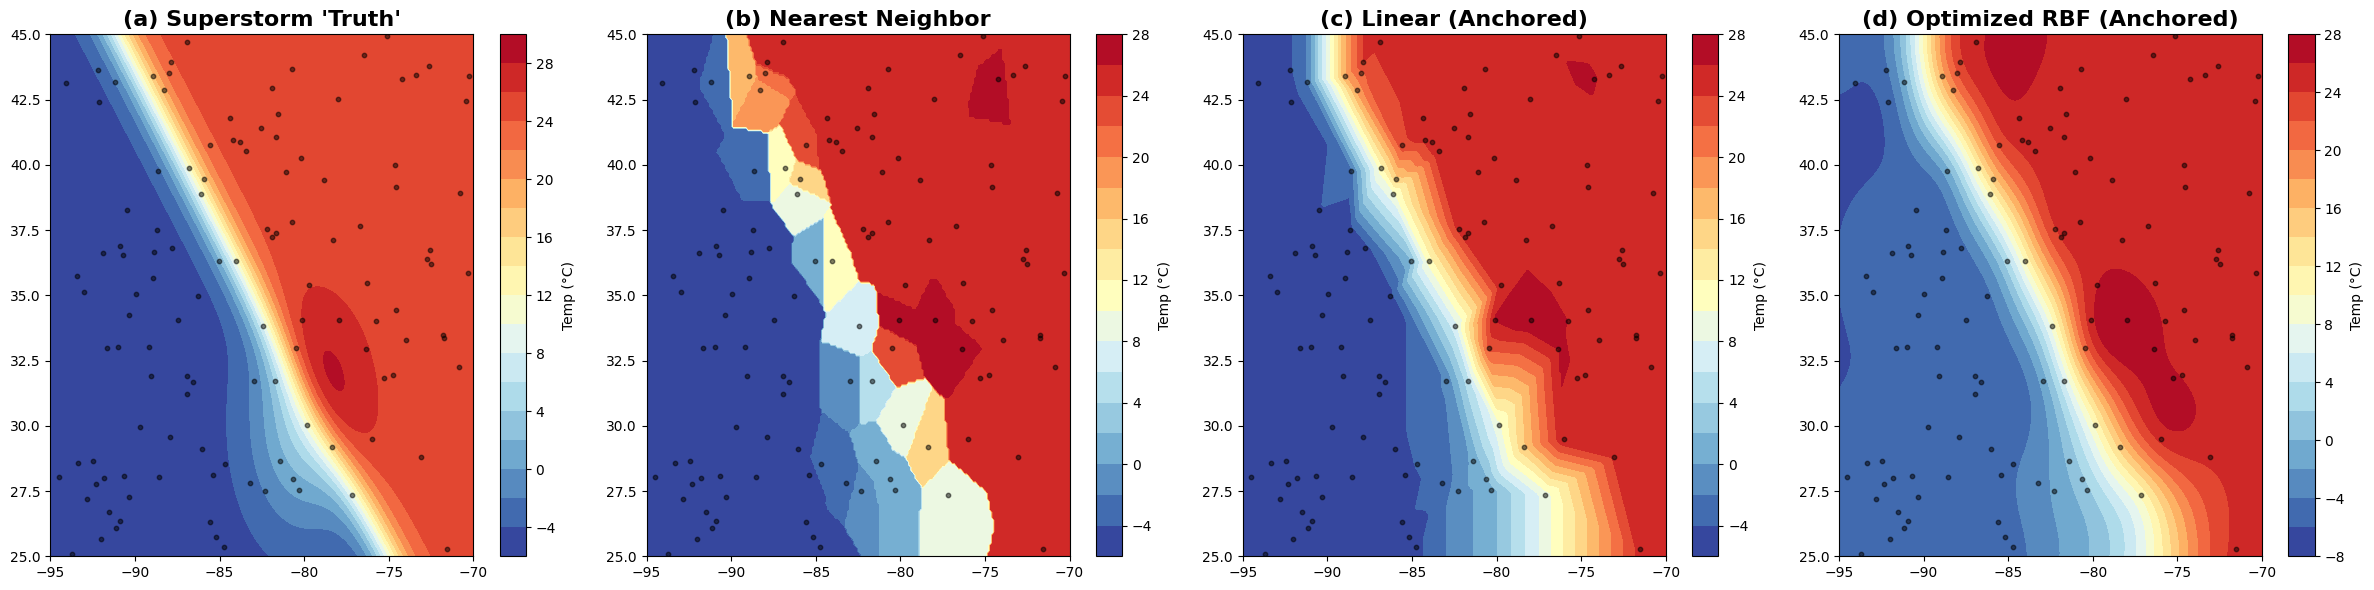

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf, NearestNDInterpolator, LinearNDInterpolator

# 1. Setup a "Continental Scale" Grid (e.g., 25N-45N, 95W-70W)
lons = np.linspace(-95, -70, 200)
lats = np.linspace(25, 45, 200)
LON, LAT = np.meshgrid(lons, lats)

# 2. Define the "Superstorm" Thermal Field (Truth)
# Tilted cold front + a warm moist tongue from the Gulf
front_line = LON + 0.8*LAT + 55
true_storm_field = 15 * np.tanh(front_line / 1.5) + 10
warm_tongue = 8 * np.exp(-((LON + 80)**2 / 10 + (LAT - 30)**2 / 15))
true_storm_field += warm_tongue

# 3. Generate Sparse 1993-era Station Sampling (N=120)
n_stations = 120
obs_lon = np.random.uniform(-95, -70, n_stations)
obs_lat = np.random.uniform(25, 45, n_stations)
# Calculate truth at stations + 0.5C instrument noise
obs_vals = (15 * np.tanh((obs_lon + 0.8*obs_lat + 55) / 1.5) + 10 +
            8 * np.exp(-((obs_lon + 80)**2 / 10 + (obs_lat - 30)**2 / 15)) +
            np.random.normal(0, 0.5, n_stations))

# --- 4. BOUNDARY ANCHORING FOR REAL CASE ---
lat_min, lat_max = 25, 45
lon_min, lon_max = -95, -70

# A) Meridional Mirroring (Y-axis / Latitude)
buffer = 4.0
near_top = obs_lat > (lat_max - buffer)
near_bottom = obs_lat < (lat_min + buffer)

ghost_lon = np.concatenate([obs_lon[near_top], obs_lon[near_bottom]])
ghost_lat = np.concatenate([2 * lat_max - obs_lat[near_top], 2 * lat_min - obs_lat[near_bottom]])
ghost_val = np.concatenate([obs_vals[near_top], obs_vals[near_bottom]])

# B) The Four Corner Snaps (To prevent the "Rhomboid" cut)
def get_corner_val(t_lon, t_lat):
    dist = (obs_lon - t_lon)**2 + (obs_lat - t_lat)**2
    return obs_vals[np.argmin(dist)]

corner_lon = np.array([lon_min, lon_max, lon_min, lon_max])
corner_lat = np.array([lat_min, lat_min, lat_max, lat_max])
corner_val = np.array([get_corner_val(lon_min, lat_min), get_corner_val(lon_max, lat_min),
                       get_corner_val(lon_min, lat_max), get_corner_val(lon_max, lat_max)])

# Combined Augmented Data
aug_lon = np.concatenate([obs_lon, ghost_lon, corner_lon])
aug_lat = np.concatenate([obs_lat, ghost_lat, corner_lat])
aug_val = np.concatenate([obs_vals, ghost_val, corner_val])

# 5. Interpolation Methods
# NN uses original data
nn_interp = NearestNDInterpolator(list(zip(obs_lon, obs_lat)), obs_vals)
nn_res = nn_interp(LON, LAT)

# Linear with Anchors
lin_interp = LinearNDInterpolator(list(zip(aug_lon, aug_lat)), aug_val)
lin_res = lin_interp(LON, LAT)

# RBF with Anchors
rbf_interp = Rbf(aug_lon, aug_lat, aug_val, function='multiquadric', epsilon=2.0, smooth=0.1)
rbf_res = rbf_interp(LON, LAT)

# 6. Visualization
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
data_list = [true_storm_field, nn_res, lin_res, rbf_res]
titles = ["(a) Superstorm 'Truth'", "(b) Nearest Neighbor",
          "(c) Linear (Anchored)", "(d) Optimized RBF (Anchored)"]

for ax, data, title in zip(axes, data_list, titles):
    im = ax.contourf(LON, LAT, data, levels=20, cmap='RdYlBu_r')
    ax.scatter(obs_lon, obs_lat, c='k', s=10, alpha=0.5)
    ax.set_title(title, fontsize=16, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Temp (°C)')

plt.savefig('Tfront.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# Figure 5 - RMSE diagnostics

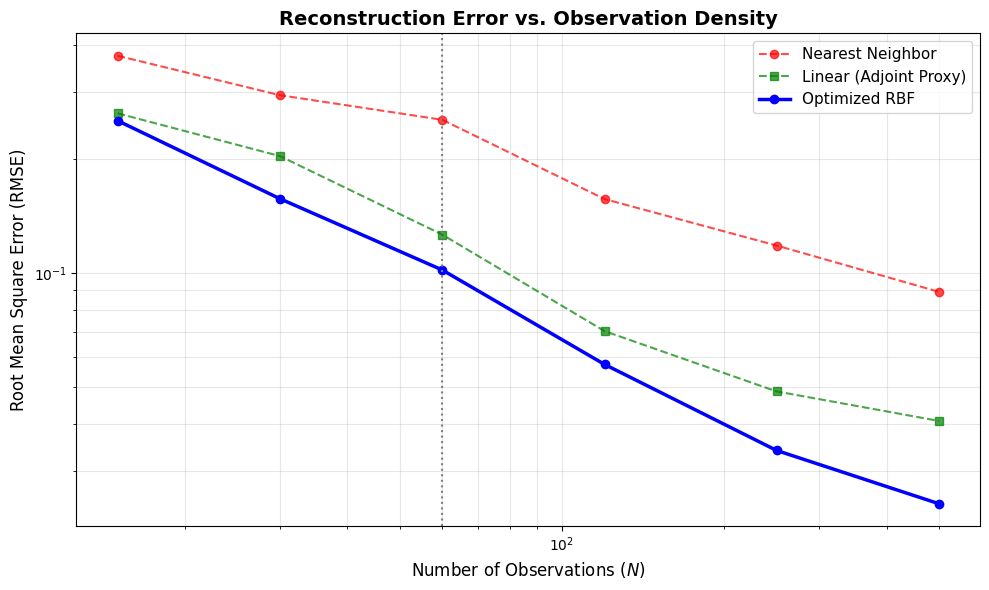

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf, NearestNDInterpolator, LinearNDInterpolator

# 1. Setup Grid and Truth (SW-NE Front)
grid_size = 150
x_coords = np.linspace(0, 10, grid_size)
y_coords = np.linspace(0, 10, grid_size)
X, Y = np.meshgrid(x_coords, y_coords)
true_field = np.tanh(-X + 0.5 * Y + 3)

def get_rmse(n):
    # Random Sampling
    obs_x = np.random.uniform(0, 10, n)
    obs_y = np.random.uniform(0, 10, n)
    obs_vals = np.tanh(-obs_x + 0.5 * obs_y + 3) + np.random.normal(0, 0.05, n)

    # --- Perfect Square Anchoring (Mirror + Corners) ---
    buffer = 2.5
    near_top, near_bottom = obs_y > 7.5, obs_y < 2.5
    gx = np.concatenate([obs_x[near_top], obs_x[near_bottom]])
    gy = np.concatenate([20 - obs_y[near_top], 0 - obs_y[near_bottom]])
    gv = np.concatenate([obs_vals[near_top], obs_vals[near_bottom]])

    # 4 Corner Snaps
    def snap(tx, ty):
        idx = np.argmin((obs_x - tx)**2 + (obs_y - ty)**2)
        return obs_vals[idx]
    cx, cy = np.array([0, 10, 0, 10]), np.array([0, 0, 10, 10])
    cv = np.array([snap(0,0), snap(10,0), snap(0,10), snap(10,10)])

    ax, ay, av = np.concatenate([obs_x, gx, cx]), np.concatenate([obs_y, gy, cy]), np.concatenate([obs_vals, gv, cv])

    # Interpolate
    nn = NearestNDInterpolator(list(zip(obs_x, obs_y)), obs_vals)(X, Y)
    lin = LinearNDInterpolator(list(zip(ax, ay)), av)(X, Y)
    rbf = Rbf(ax, ay, av, function='multiquadric', epsilon=1.2, smooth=0.1)(X, Y)

    return [np.sqrt(np.mean((true_field - m)**2)) for m in [nn, lin, rbf]]

# 2. Run the Study
densities = [15, 30, 60, 120, 250, 500]
results = np.array([get_rmse(n) for n in densities])

# 3. Visualization for MDPI
plt.figure(figsize=(10, 6))
plt.plot(densities, results[:, 0], 'ro--', label='Nearest Neighbor', alpha=0.7)
plt.plot(densities, results[:, 1], 'gs--', label='Linear (Adjoint Proxy)', alpha=0.7)
plt.plot(densities, results[:, 2], 'bo-', linewidth=2.5, label='Optimized RBF')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Observations ($N$)', fontsize=12)
plt.ylabel('Root Mean Square Error (RMSE)', fontsize=12)
plt.title('Reconstruction Error vs. Observation Density', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.3)

# Add a note about the Rossby Radius
plt.savefig('Dgns.png', bbox_inches='tight', dpi=300)
plt.axvline(x=60, color='gray', linestyle=':', label='Approx. Rossby Limit')
plt.tight_layout()
plt.show()

# Figure 6 - Various RBF Kernels

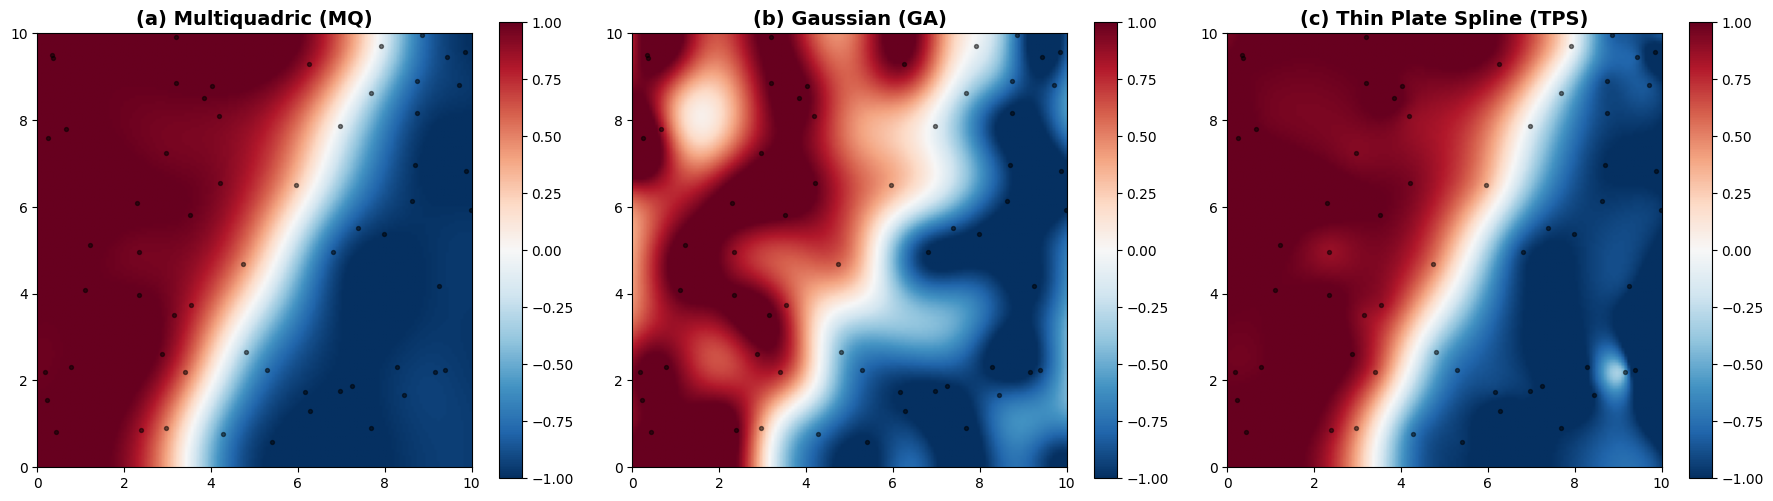

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf

# 1. Setup Grid and Truth (SW-NE Front)
grid_size = 150
x = np.linspace(0, 10, grid_size)
y = np.linspace(0, 10, grid_size)
X, Y = np.meshgrid(x, y)
true_field = np.tanh(-X + 0.5 * Y + 3)

# 2. Generate Sparse Observations (N=60 to show differences)
n_obs = 60
obs_x = np.random.uniform(0, 10, n_obs)
obs_y = np.random.uniform(0, 10, n_obs)
obs_values = np.tanh(-obs_x + 0.5 * obs_y + 3) + np.random.normal(0, 0.05, n_obs)

# --- 3. BOUNDARY ANCHORING (Consistent with previous scripts) ---
def get_anchors(ox, oy, ov):
    # Mirroring Y
    near_t, near_b = oy > 7.5, oy < 2.5
    gx = np.concatenate([ox[near_t], ox[near_b]])
    gy = np.concatenate([20 - oy[near_t], 0 - oy[near_b]])
    gv = np.concatenate([ov[near_t], ov[near_b]])
    # 4 Corners
    cx, cy = np.array([0, 10, 0, 10]), np.array([0, 0, 10, 10])
    cv = [ov[np.argmin((ox-tx)**2 + (oy-ty)**2)] for tx, ty in zip(cx, cy)]
    return np.concatenate([ox, gx, cx]), np.concatenate([oy, gy, cy]), np.concatenate([ov, gv, cv])

ax, ay, av = get_anchors(obs_x, obs_y, obs_values)

# 4. Compare Kernels
kernels = ['multiquadric', 'gaussian', 'thin_plate']
titles = ["(a) Multiquadric (MQ)", "(b) Gaussian (GA)", "(c) Thin Plate Spline (TPS)"]
results = []

for k in kernels:
    # Note: TPS does not use epsilon in the same way, but Rbf handles it
    rbf = Rbf(ax, ay, av, function=k, epsilon=1.2, smooth=0.1)
    results.append(rbf(X, Y))

# 5. Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_plot, res, title in zip(axes, results, titles):
    im = ax_plot.imshow(res, extent=(0, 10, 0, 10), origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
    ax_plot.scatter(obs_x, obs_y, c='black', s=8, alpha=0.5)
    ax_plot.set_title(title, fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax_plot)

plt.savefig('RBFfront.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# Figure 7 - Convergence of various RBF kernels

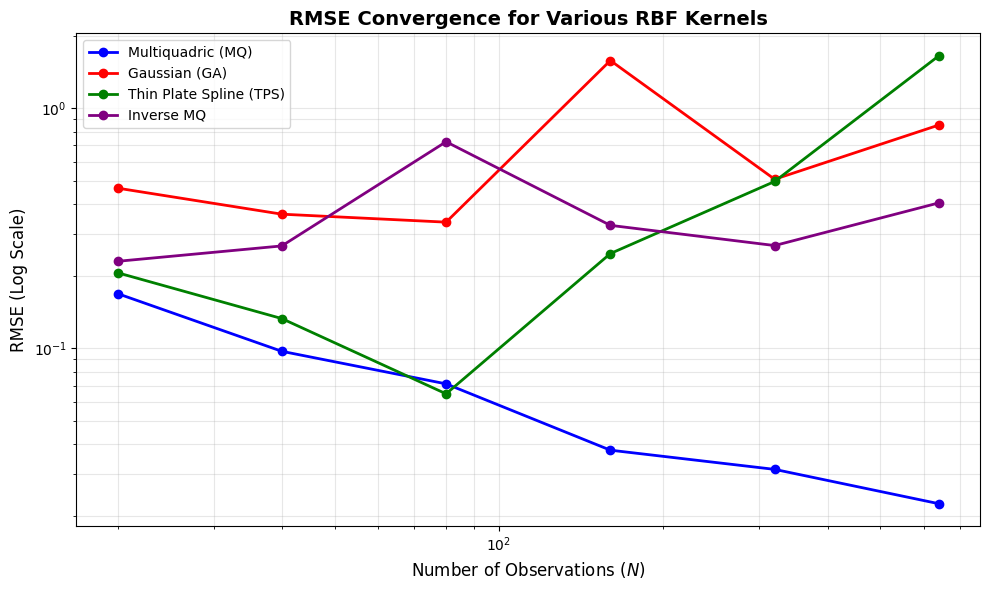

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf

# 1. Setup Grid and Truth (SW-NE Front)
grid_size = 150
x_coords = np.linspace(0, 10, grid_size)
y_coords = np.linspace(0, 10, grid_size)
X, Y = np.meshgrid(x_coords, y_coords)
true_field = np.tanh(-X + 0.5 * Y + 3)

def get_kernel_rmse(n, kernel_type):
    # Random Sampling
    obs_x = np.random.uniform(0, 10, n)
    obs_y = np.random.uniform(0, 10, n)
    obs_vals = np.tanh(-obs_x + 0.5 * obs_y + 3) + np.random.normal(0, 0.05, n)

    # --- Perfect Square Anchoring (Mirror + Corners) ---
    buffer = 2.5
    near_top, near_bottom = obs_y > 7.5, obs_y < 2.5
    gx = np.concatenate([obs_x[near_top], obs_x[near_bottom]])
    gy = np.concatenate([20 - obs_y[near_top], 0 - obs_y[near_bottom]])
    gv = np.concatenate([obs_vals[near_top], obs_vals[near_bottom]])

    def snap(tx, ty):
        idx = np.argmin((obs_x - tx)**2 + (obs_y - ty)**2)
        return obs_vals[idx]
    cx, cy = np.array([0, 10, 0, 10]), np.array([0, 0, 10, 10])
    cv = np.array([snap(0,0), snap(10,0), snap(0,10), snap(10,10)])

    ax, ay, av = np.concatenate([obs_x, gx, cx]), np.concatenate([obs_y, gy, cy]), np.concatenate([obs_vals, gv, cv])

    # Interpolate using specific kernel
    try:
        rbf = Rbf(ax, ay, av, function=kernel_type, epsilon=1.2, smooth=0.1)
        res = rbf(X, Y)
        return np.sqrt(np.mean((true_field - res)**2))
    except:
        return np.nan # Catch ill-conditioning issues common with Gaussians

# 2. Run the Multi-Density Study
densities = [20, 40, 80, 160, 320, 640]
kernels = ['multiquadric', 'gaussian', 'thin_plate', 'inverse']
labels = ['Multiquadric (MQ)', 'Gaussian (GA)', 'Thin Plate Spline (TPS)', 'Inverse MQ']
colors = ['blue', 'red', 'green', 'purple']

plt.figure(figsize=(10, 6))

for k, lbl, col in zip(kernels, labels, colors):
    errors = [get_kernel_rmse(n, k) for n in densities]
    plt.plot(densities, errors, marker='o', linestyle='-', color=col, label=lbl, linewidth=2)

# 3. Formatting for Publication
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Observations ($N$)', fontsize=12)
plt.ylabel('RMSE (Log Scale)', fontsize=12)
plt.title('RMSE Convergence for Various RBF Kernels', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.savefig('CONVfront.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()